# 9. End-to-End Image Processing: M 13

In this User Guide Cookbook, you will learn how to process a single real dataset (M 13) through all the available pipelines in a single workflow.

This notebook serves as a quick reference for running the full Astrometrics pipeline end-to-end, skipping the deep explanatory text found in the earlier modular guides. It is self-contained: it registers the bundled sample data itself rather than depending on notebook 1 having run first.

You will see how to:
1. Initialize the `Astrometrics` high-level interface and load the bundled M 13 sample data.
2. Stack and calibrate raw images.
3. Perform astrometry and plate-solving.
4. Run differential photometry.
5. Extract 1D spectra.


In [1]:
from astrometricslib import Astrometrics
from documentation.notebooks.astrometrics.scripts.sample_data_staging import (
    drop_stale_sample_data_frames,
    stage_m13_sample_data,
)

astrometrics = Astrometrics()

# Imaging (Luminance) and spectroscopy frames are registered on separate
# targets -- astrometricslib refuses to mix SPEC and standard frames on
# one target -- so the imaging pipelines run against "M 13" and the
# spectroscopy pipeline against "M 13 Spectroscopy".
imaging_target = astrometrics.targets.get("M 13") or astrometrics.targets.create("M 13")
spectroscopy_target = astrometrics.targets.get("M 13 Spectroscopy") or astrometrics.targets.create(
    "M 13 Spectroscopy"
)
drop_stale_sample_data_frames(imaging_target)
drop_stale_sample_data_frames(spectroscopy_target)

sample_data_dir = stage_m13_sample_data()
for path in sorted(sample_data_dir.glob("M_13_Light_Luminance_*.fits")):
    if not any(f.path == str(path) for f in imaging_target.frames):
        astrometrics.targets.add_frame(imaging_target, path=str(path), role="LIGHT")
for path in sorted(sample_data_dir.glob("M_13_Light_Spectroscopy_*.fits")):
    if not any(f.path == str(path) for f in spectroscopy_target.frames):
        astrometrics.targets.add_frame(spectroscopy_target, path=str(path), role="LIGHT")
astrometrics.targets.save()

print(f"Loaded '{imaging_target.id}' with {len(imaging_target.frames)} registered frames.")
print(f"Loaded '{spectroscopy_target.id}' with {len(spectroscopy_target.frames)} registered frames.")

Loaded 'M 13' with 5 registered frames.
Loaded 'M 13 Spectroscopy' with 5 registered frames.


## 2. Inspecting Frame Records

Every frame in `imaging_target.frames` is a Luminance light frame, taken through a clear filter that passes all visible light.

Every frame in `spectroscopy_target.frames` is a slitless spectroscopy exposure. Slitless means the spectrum was produced by a grating placed in the light path, rather than by light passing through a narrow slit first. Each star in the field spreads into its own small spectrum.


In [2]:
luminance_frames = imaging_target.frames
spectroscopy_frames = spectroscopy_target.frames

print(f"Luminance frames: {len(luminance_frames)}")
print(f"Spectroscopy frames: {len(spectroscopy_frames)}")

Luminance frames: 5
Spectroscopy frames: 5


## 3. Stacking Luminance Frames (`stacked_image`)

We stack the Luminance exposures with `astrometrics.processing.run_stacking`.

Stacking averages the frames together, which raises the signal relative to the noise. Before averaging, the pipeline applies Chauvenet rejection: for each pixel position, it discards any value sitting further from the average than a sample of that size should plausibly produce. This is what removes satellite trails and cosmic ray hits, which appear in one frame but not the rest.


In [3]:
print(f"Stacking Luminance frames for {imaging_target.id}...")
stacked_image = astrometrics.processing.run_stacking(imaging_target, filter_type="Luminance")
if stacked_image:
    imaging_target.stacked_image = stacked_image
    astrometrics.targets.save()
print(f"Luminance master stack: {stacked_image}")

Stacking Luminance frames for M 13...


Luminance master stack: /home/user/astrometrics/astrometricslib/libraryIndex/frames/lights/M 13/M_13_L_Stacked.fits


## 4. Stacking Spectroscopy Frames (`stacked_spectral_target`)

We execute frame stacking on the slitless spectroscopy (`SPEC`) exposures using `astrometrics.processing.run_stacking`.

In [4]:
print(f"Stacking Spectroscopy frames for {spectroscopy_target.id}...")
stacked_spectral_image = astrometrics.processing.run_stacking(spectroscopy_target, filter_type="SPEC")
if stacked_spectral_image:
    spectroscopy_target.stacked_spectral_target = stacked_spectral_image
    astrometrics.targets.save()
print(f"Spectroscopy master stack: {stacked_spectral_image}")

Stacking Spectroscopy frames for M 13 Spectroscopy...


Spectroscopy master stack: /home/user/astrometrics/astrometricslib/libraryIndex/frames/lights/M 13 Spectroscopy/M_13_Spectroscopy_SPEC_Stacked.fits


## 5. Running Astrometry Analysis

We run plate solving and catalog cross-matching on the master Luminance image with `astrometrics.processing.run_astrometry`.

Plate solving works out which patch of sky an image shows, by matching the pattern of stars in it against a catalog. The answer is written into the image's FITS header as a WCS (World Coordinate System), the mapping that turns a pixel position into a sky coordinate.

This step needs one of two things: a local `solve-field` install whose index files match how much sky your camera and telescope see, or an astrometry.net API key. See `documentation/Installation.md`.


In [5]:
print(f"Running astrometry plate-solving for {imaging_target.id}...")
astrometry_result = astrometrics.processing.run_astrometry(imaging_target)
print(f"Astrometry solved: {astrometry_result.get('wcs') is not None}")
print(f"Stars detected: {len(astrometry_result.get('stellar_objects', []))}")

Running astrometry plate-solving for M 13...


Astrometry solved: True
Stars detected: 500


## 6. Running Photometry Analysis

We perform aperture photometry and ensemble calibration across the Luminance frame sequence using `astrometrics.processing.run_photometry`.

In [6]:
print(f"Running ensemble photometry for {imaging_target.id}...")
photometry_result = astrometrics.processing.run_photometry(
    imaging_target,
    filter_type="Luminance",
    frames=luminance_frames,
    use_astrometry_seed=True,
)
print(f"Photometry status: {photometry_result.get('status')}")
print(f"Stars found: {photometry_result.get('starsFound', 0)}")

Running ensemble photometry for M 13...


Photometry status: completed
Stars found: 493


## 7. Running Spectroscopy Analysis

We detect zero-order star centroids and extract calibrated 1D spectra from the dispersed spectral image using `astrometrics.processing.run_spectroscopy`.

In [7]:
print(f"Running spectroscopy analysis for {spectroscopy_target.id}...")
spectroscopy_result = astrometrics.processing.run_spectroscopy(spectroscopy_target)
spectral_stars = spectroscopy_result.get("stellar_objects", [])
print(f"Spectroscopy extracted {len(spectral_stars)} spectra.")

summary = getattr(spectroscopy_target, "spectroscopy_quality_summary", None)
print(f"Spectroscopy Pipeline Status: {'flagged' if summary and summary.flagged else 'completed'}")

concerns = summary.spectroscopy_metrics.flagged_spectral_classifications if summary else []
if concerns:
    print(f"\nSelf-determined spectral type is uncertain for {len(concerns)} star(s):")
    for concern in concerns:
        print(
            f"  {concern.star_id}: {concern.spectral_type} "
            f"({concern.reason}, confidence={concern.confidence:.2f})"
        )

Running spectroscopy analysis for M 13 Spectroscopy...


Spectroscopy extracted 9 spectra.
Spectroscopy Pipeline Status: flagged

Self-determined spectral type is uncertain for 2 star(s):
  HD 150998::spectroscopy: K5V (ambiguous, confidence=0.93)
  HD 150579::spectroscopy: O5V (low_confidence, confidence=0.33)


## 8. Querying Enriched Stellar Catalog

We list and inspect the solved stellar objects associated with **M 13** via `astrometrics.stars.list_objects`.

In [8]:
stellar_objects = [obj for obj in astrometrics.stars.list_objects() if imaging_target.id in obj.target_ids]
print(f"Retrieved {len(stellar_objects)} stellar objects for target {imaging_target.id}.")
if stellar_objects:
    sample_star = stellar_objects[0]
    print(f"Sample Star: ID={sample_star.id}, Name={sample_star.name}, Mag={sample_star.magnitude}")

Retrieved 474 stellar objects for target M 13.
Sample Star: ID=NGC  6205   620, Name=NGC  6205   620, Mag=13.199999809265137


## 9. Visualizing Results with Interactive Dashboards

We visualize the comprehensive multi-modal analysis results using the high-level `astrometrics.visualization` tools.

### 9.1 Interactive Target Dashboard

The target dashboard displays the FITS image with astrometric star overlays alongside side panels for photometry and spectroscopy that update dynamically when clicking stars.

Rendering interactive target dashboard for M 13...


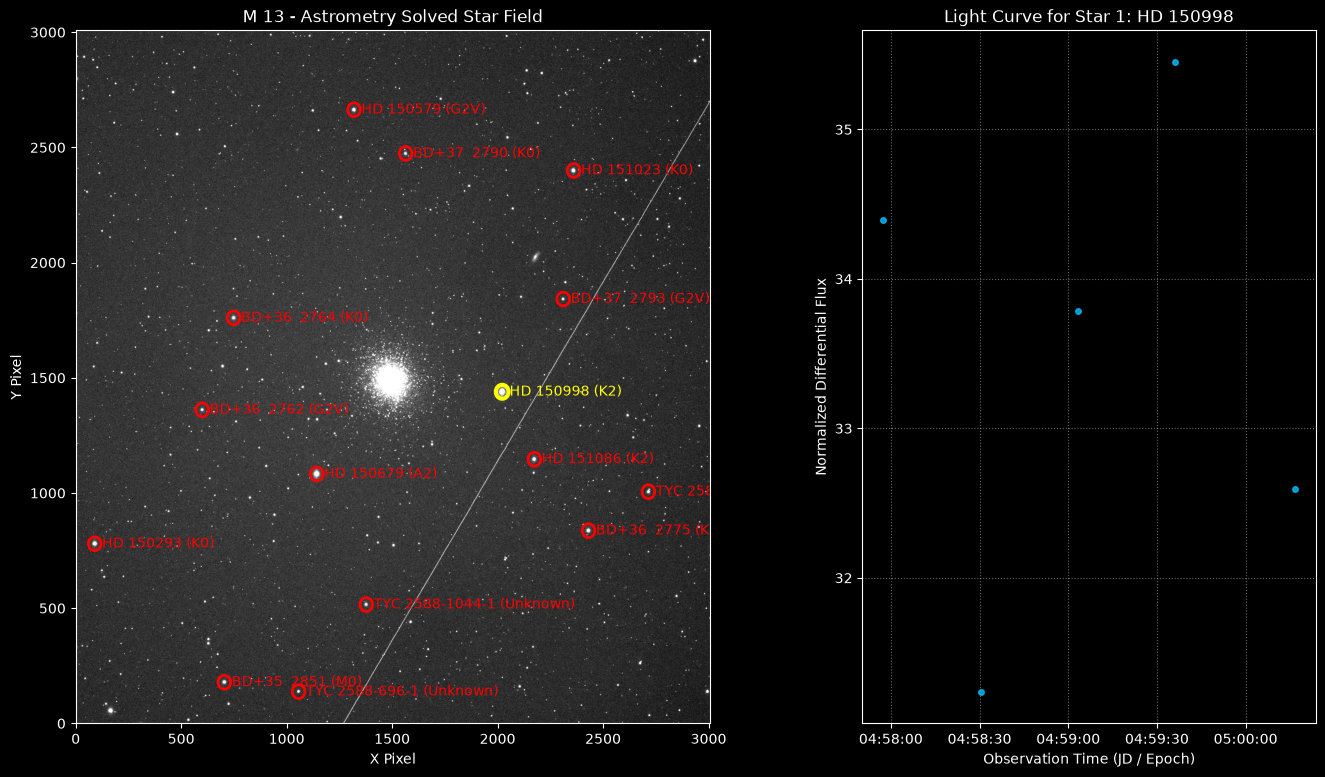

In [9]:
print(f"Rendering interactive target dashboard for {imaging_target.id}...")
figure = astrometrics.visualization.plot_target_dashboard(imaging_target)
figure.show()

### 9.2 Star Multi-Modal Analysis Dashboard

The star dashboard displays a two-panel visualization for a single star showing its photometric light curve and calibrated 1D spectrum.

Rendering star dashboard for NGC  6205   620...


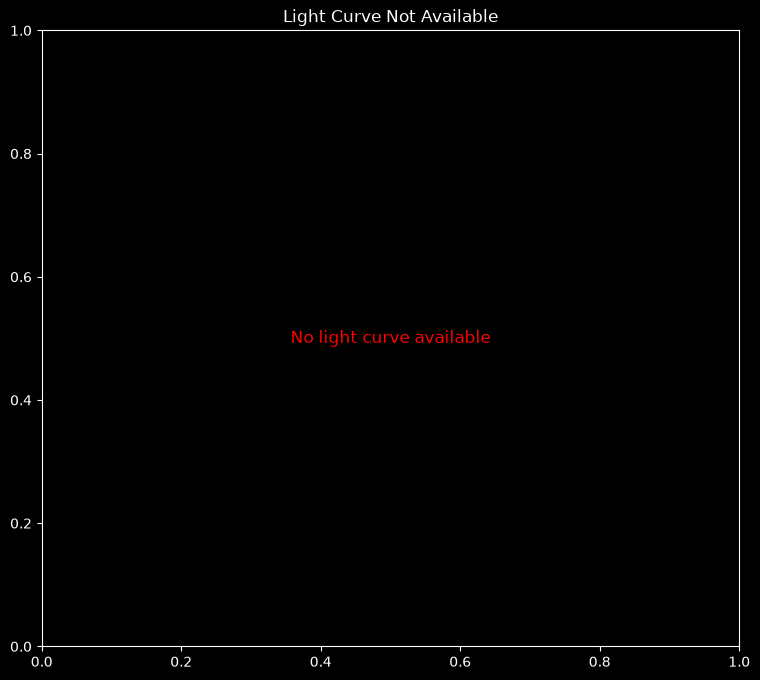

In [10]:
if stellar_objects:
    selected_star = stellar_objects[0]
    spectral_star = astrometrics.stars.get_object(f"{selected_star.id}::spectroscopy")
    print(f"Rendering star dashboard for {selected_star.id}...")
    star_figure = astrometrics.visualization.plot_star_dashboard(selected_star, spectral_star=spectral_star)
    star_figure.show()
else:
    print("No stellar objects were identified for this target; skipping the star dashboard.")

## Summary

You have learned how to:
1. Load a real dataset onto separate imaging and spectroscopy targets.
2. Execute Chauvenet rejection stacking for luminance and spectroscopy frames via `astrometrics.processing.run_stacking`.
3. Solve astrometry, extract photometry, and calibrate 1D spectra using explicit `astrometrics.processing.run_*` methods.
4. Inspect multi-modal results using `astrometrics.visualization.plot_target_dashboard` and `astrometrics.visualization.plot_star_dashboard`.